# 3. Oscillations in Mass Flux

But why is a 90-minute oscillation in the cloud size distribution significant?

I have examined the properties of the cloud field, and it appears that the total mass flux of the cloud field has a close relationship with the slope of the cloud size distribution. Here, I repeat the GP regression workflow from the previous notebook for mass flux.

In [173]:
# Set up local project directory path
from pathlib import Path
from tqdm.notebook import tqdm
import sys

project_src = Path('../src').resolve().as_posix()
sys.path.insert(0, project_src)

try:
    import lib.config
except Exception:
    raise Exception("Issue with dynamic import")

# config = lib.config.read_config()
# pwd = Path(config['pwd'])
# case = Path(config['case'])

In [174]:
# Import modules needed for the rest of the notebook
import numpy as np
import xarray as xr
import pandas as pd

import sklearn.preprocessing as skl_prep
from statsmodels.nonparametric import smoothers_lowess as sl

# Pytorch + GP
import torch, gpytorch

In [175]:
# CUDA setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

if device.type == 'cuda':
    print(f"Using {torch.cuda.get_device_name(0)}")
else:
    print(f"Using {device}")

Using mps


In [176]:
import matplotlib as mpl
from matplotlib import pyplot as plt

import seaborn as sns

sns.set_context('notebook')
sns.set_style('ticks', 
    {
        'axes.grid': True, 
        'axes.linewidth': '1',
        'xtick.labelsize' : 12,
        'ytick.labelsize' : 12,
        'grid.color': '0.5',
        'grid.linestyle': u':',
        'legend.frameon': True,
    })
xkcd = sns.xkcd_rgb


rc_opt = {
    "figure.dpi": 300,
    "font.family": "serif",
    "font.size": 15,
    "text.usetex": False,
    'text.latex.preamble': r"\usepackage{libertine} \usepackage[libertine]{newtxmath}",
}
mpl.rcParams.update(rc_opt)

In [177]:
p = Path("../nc/CGILS_1728x576x192_25m_1s_ent.nc")

df = xr.open_dataset(p)
df

<xarray.Dataset> Size: 1GB
Dimensions:     (z: 192, time: 2880)
Coordinates:
  * z           (z) float32 768B 12.5 37.5 62.5 ... 4.762e+03 4.788e+03
  * time        (time) float32 12kB 196.0 196.0 196.0 ... 198.0 198.0 198.0
Data variables: (12/712)
    p           (z) float32 768B ...
    SST         (time) float32 12kB ...
    Ps          (time) float32 12kB ...
    CLDSHD      (time) float32 12kB ...
    AREAPREC    (time) float32 12kB ...
    CLD245      (time) float32 12kB ...
    ...          ...
    EQROMCOR    (time, z) float32 2MB ...
    DQROMCOR    (time, z) float32 2MB ...
    ETROMCOR    (time, z) float32 2MB ...
    DTROMCOR    (time, z) float32 2MB ...
    EWROMCOR    (time, z) float32 2MB ...
    DWROMCOR    (time, z) float32 2MB ...
Attributes:
    SAM version:  
    caseid:       1728x576x192_25m_1s_ent

In [178]:
y = np.array(np.nanmean(df.MFCOR.T, axis=0)[1440:2160])
x = np.arange(len(y))

x_full = torch.tensor(x[:], dtype=torch.double)
y_full = torch.tensor(y[:], dtype=torch.double)

x_tr = torch.tensor(x[:600], dtype=torch.double)
y_tr = torch.tensor(y[:600], dtype=torch.double)

 The following plot shows the timeseries of total mass flux. Again, it looks very noisy and the oscillatory behaviour is not evident at all. The workflow remains exactly the same as the cloud size distribution, so I will skip the comments.

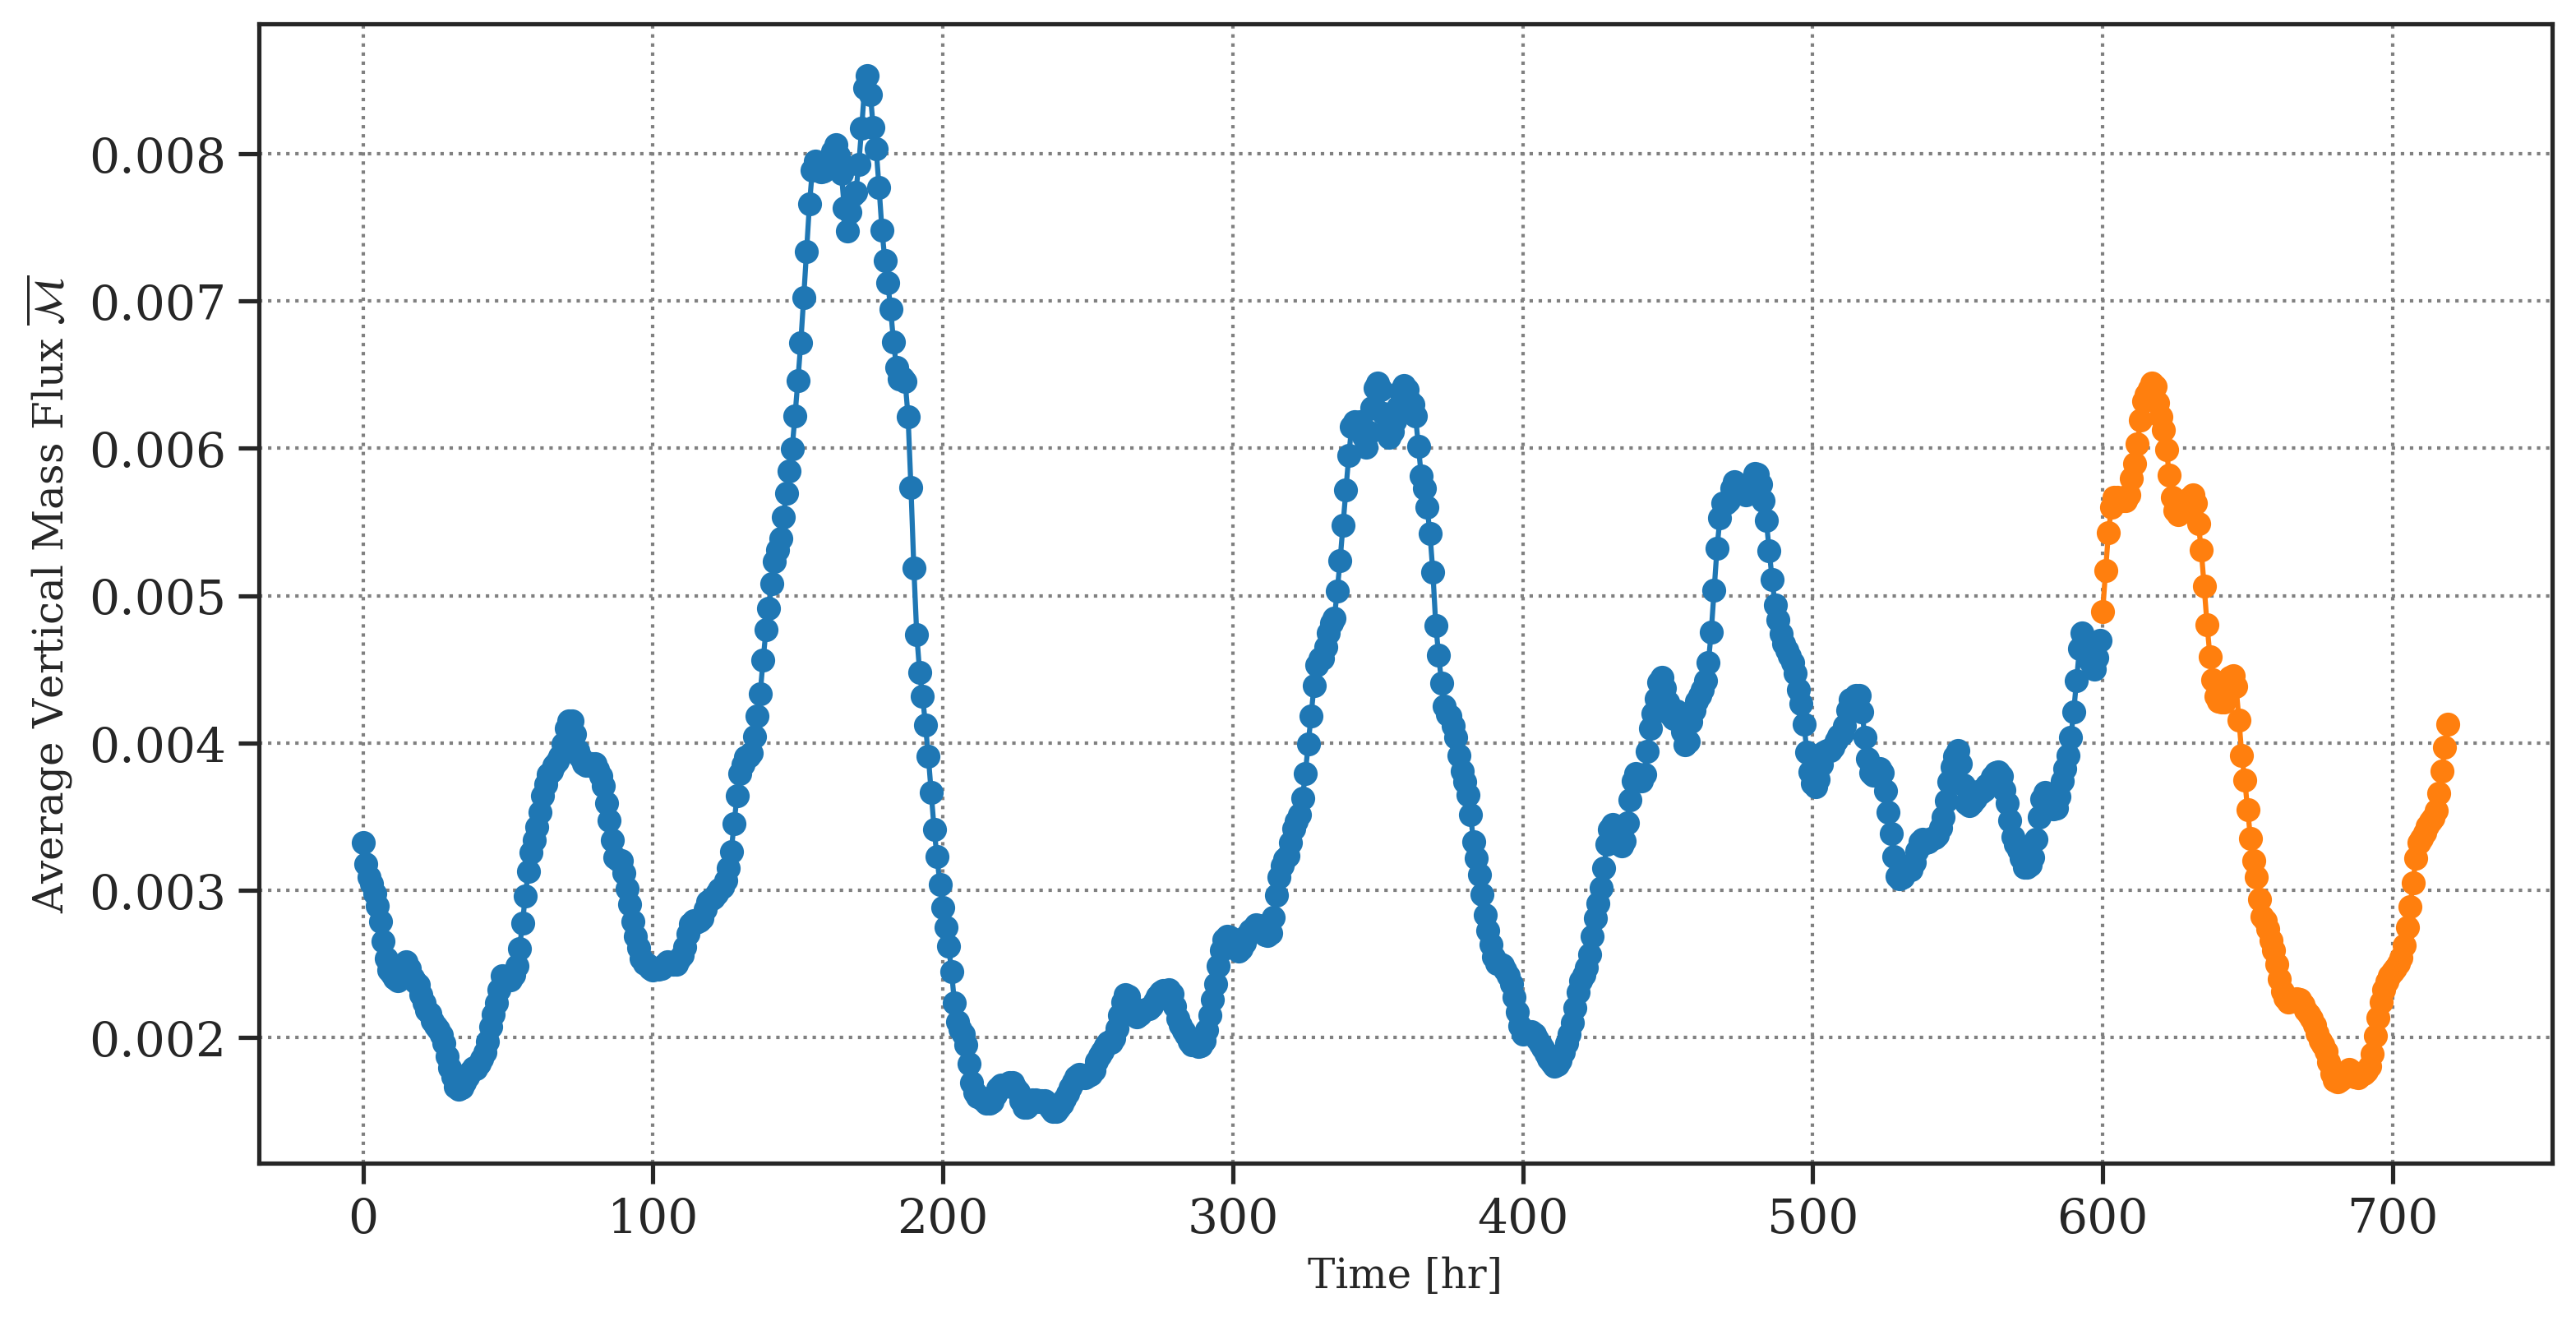

In [179]:
# Plot
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.plot(x_full[:600], y_full[:600], 'o-', label="Training")
ax.plot(x_full[600:], y_full[600:], 'o-', label="Testing")

ax.set_xlabel("Time [hr]")
ax.set_ylabel("Average Vertical Mass Flux $\overline{\mathcal{M}}$")

ax.tick_params(axis="both", which="major", labelsize=14)

In [180]:
class SmoothGPModel(gpytorch.models.ExactGP):
    def __init__(self, x_tr, y_tr, likelihood):
        super(SmoothGPModel, self).__init__(x_tr, y_tr, likelihood)
        
        self.mean_module = gpytorch.means.ConstantMean()
        
        self.cov_module = gpytorch.kernels.AdditiveKernel(
            gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel()),
            gpytorch.kernels.ScaleKernel(gpytorch.kernels.PeriodicKernel()),
        )

    def forward(self, x):
        x_mean = self.mean_module(x)
        x_cov = self.cov_module(x)
        
        return gpytorch.distributions.MultivariateNormal(x_mean, x_cov)

In [181]:
# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint = gpytorch.constraints.Positive(),
    noise_prior = gpytorch.priors.NormalPrior(1e-2, 1),
)
model = SmoothGPModel(x_tr, y_tr, likelihood)

# Initialize kernels
model.cov_module.kernels[0].base_kernel.initialize(
    lengthscale = torch.tensor(50)
)

model.cov_module.kernels[1].base_kernel.initialize(
    lengthscale = torch.tensor(50.),
    period_length = torch.tensor(95.),
)

model.double()

SmoothGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): NormalPrior()
      (raw_noise_constraint): Positive()
    )
  )
  (mean_module): ConstantMean()
  (cov_module): AdditiveKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): RBFKernel(
          (raw_lengthscale_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
      (1): ScaleKernel(
        (base_kernel): PeriodicKernel(
          (raw_lengthscale_constraint): Positive()
          (raw_period_length_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
    )
  )
)

In [182]:
# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam([{'params': model.parameters()},], lr=1e-1)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

max_iter = 200
losses = []

p_bar = tqdm(range(max_iter))
for i in p_bar:
    optimizer.zero_grad()
    output = model(x_tr)
    loss = -mll(output, y_tr)
    losses += [loss.item()]
    loss.backward()

    p_status = f"{i + 1:3d}/{max_iter:3d} Loss: {loss.item():.3f}"
    p_bar.set_description(p_status)
    
    optimizer.step()

  0%|          | 0/200 [00:00<?, ?it/s]

In [183]:
# Model parameters
for param_name, param in model.named_parameters():
    print(f"{param_name:42} \t {param.item()}")

likelihood.noise_covar.raw_noise           	 -16.993454831699417
mean_module.raw_constant                   	 -0.0024107534781951595
cov_module.kernels.0.raw_outputscale       	 -4.319757947764621
cov_module.kernels.0.base_kernel.raw_lengthscale 	 42.88059880553228
cov_module.kernels.1.raw_outputscale       	 -8.332378008880122
cov_module.kernels.1.base_kernel.raw_lengthscale 	 56.61963759495286
cov_module.kernels.1.base_kernel.raw_period_length 	 83.22416100120742


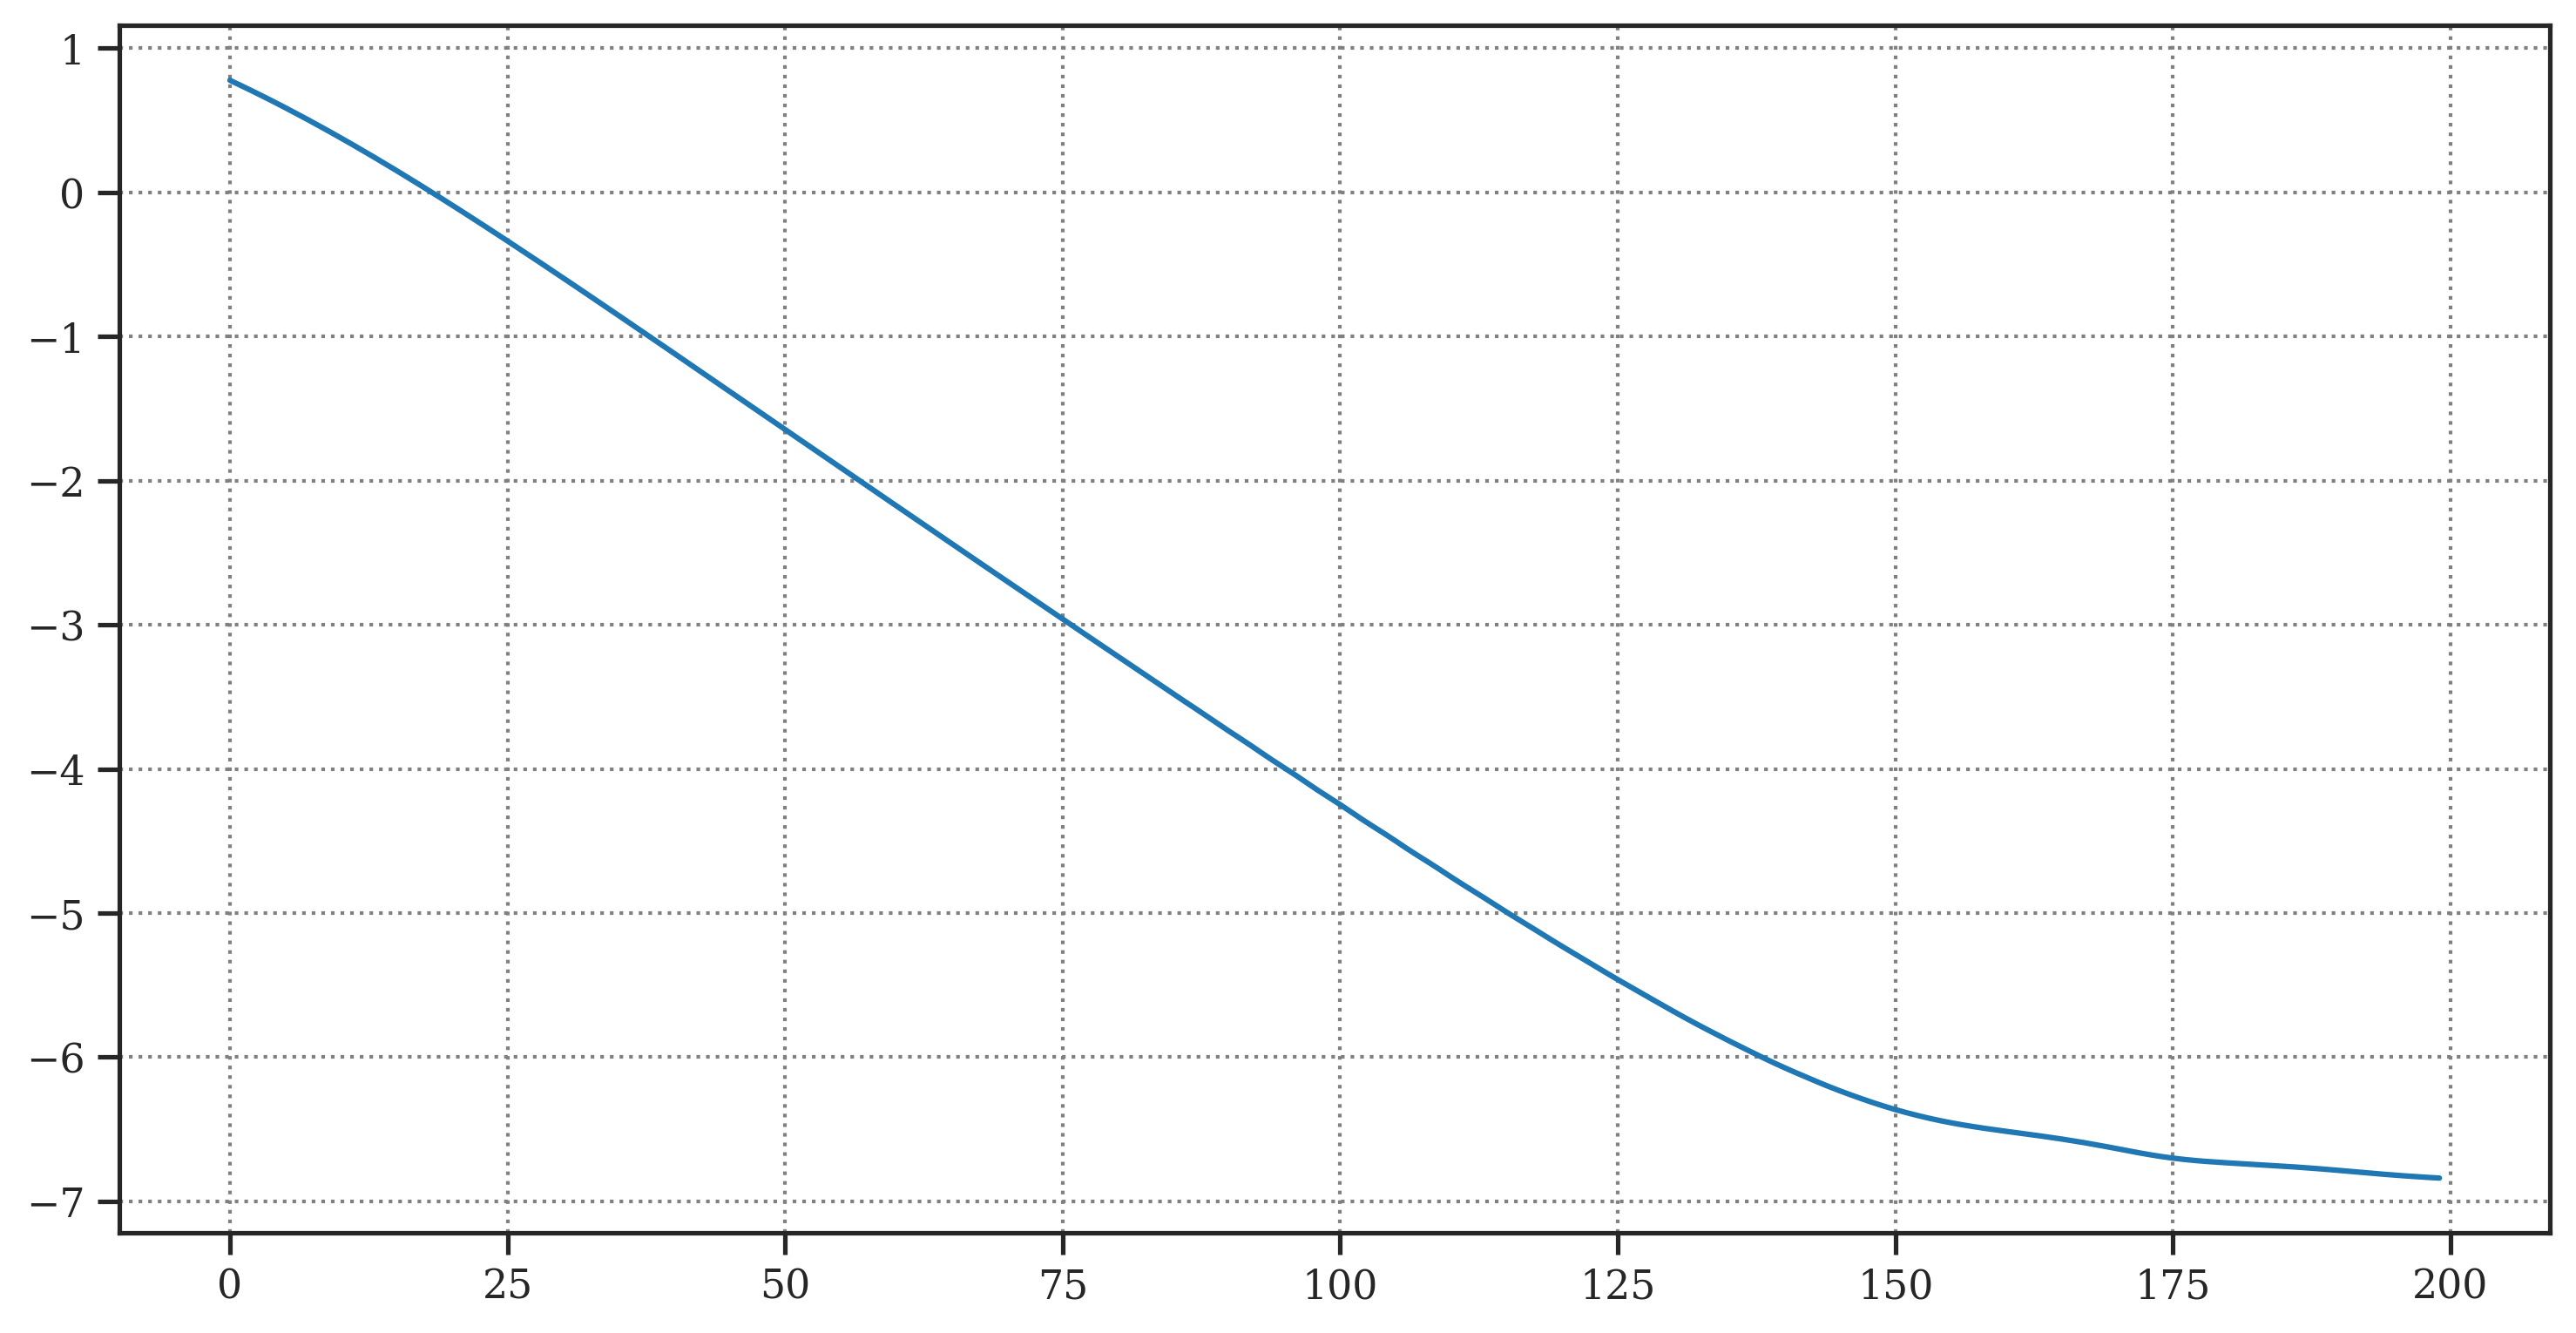

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(np.arange(len(losses)), losses)

/Users/lorenoh/.local/opt/mamba/envs/stats/lib/python3.10/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


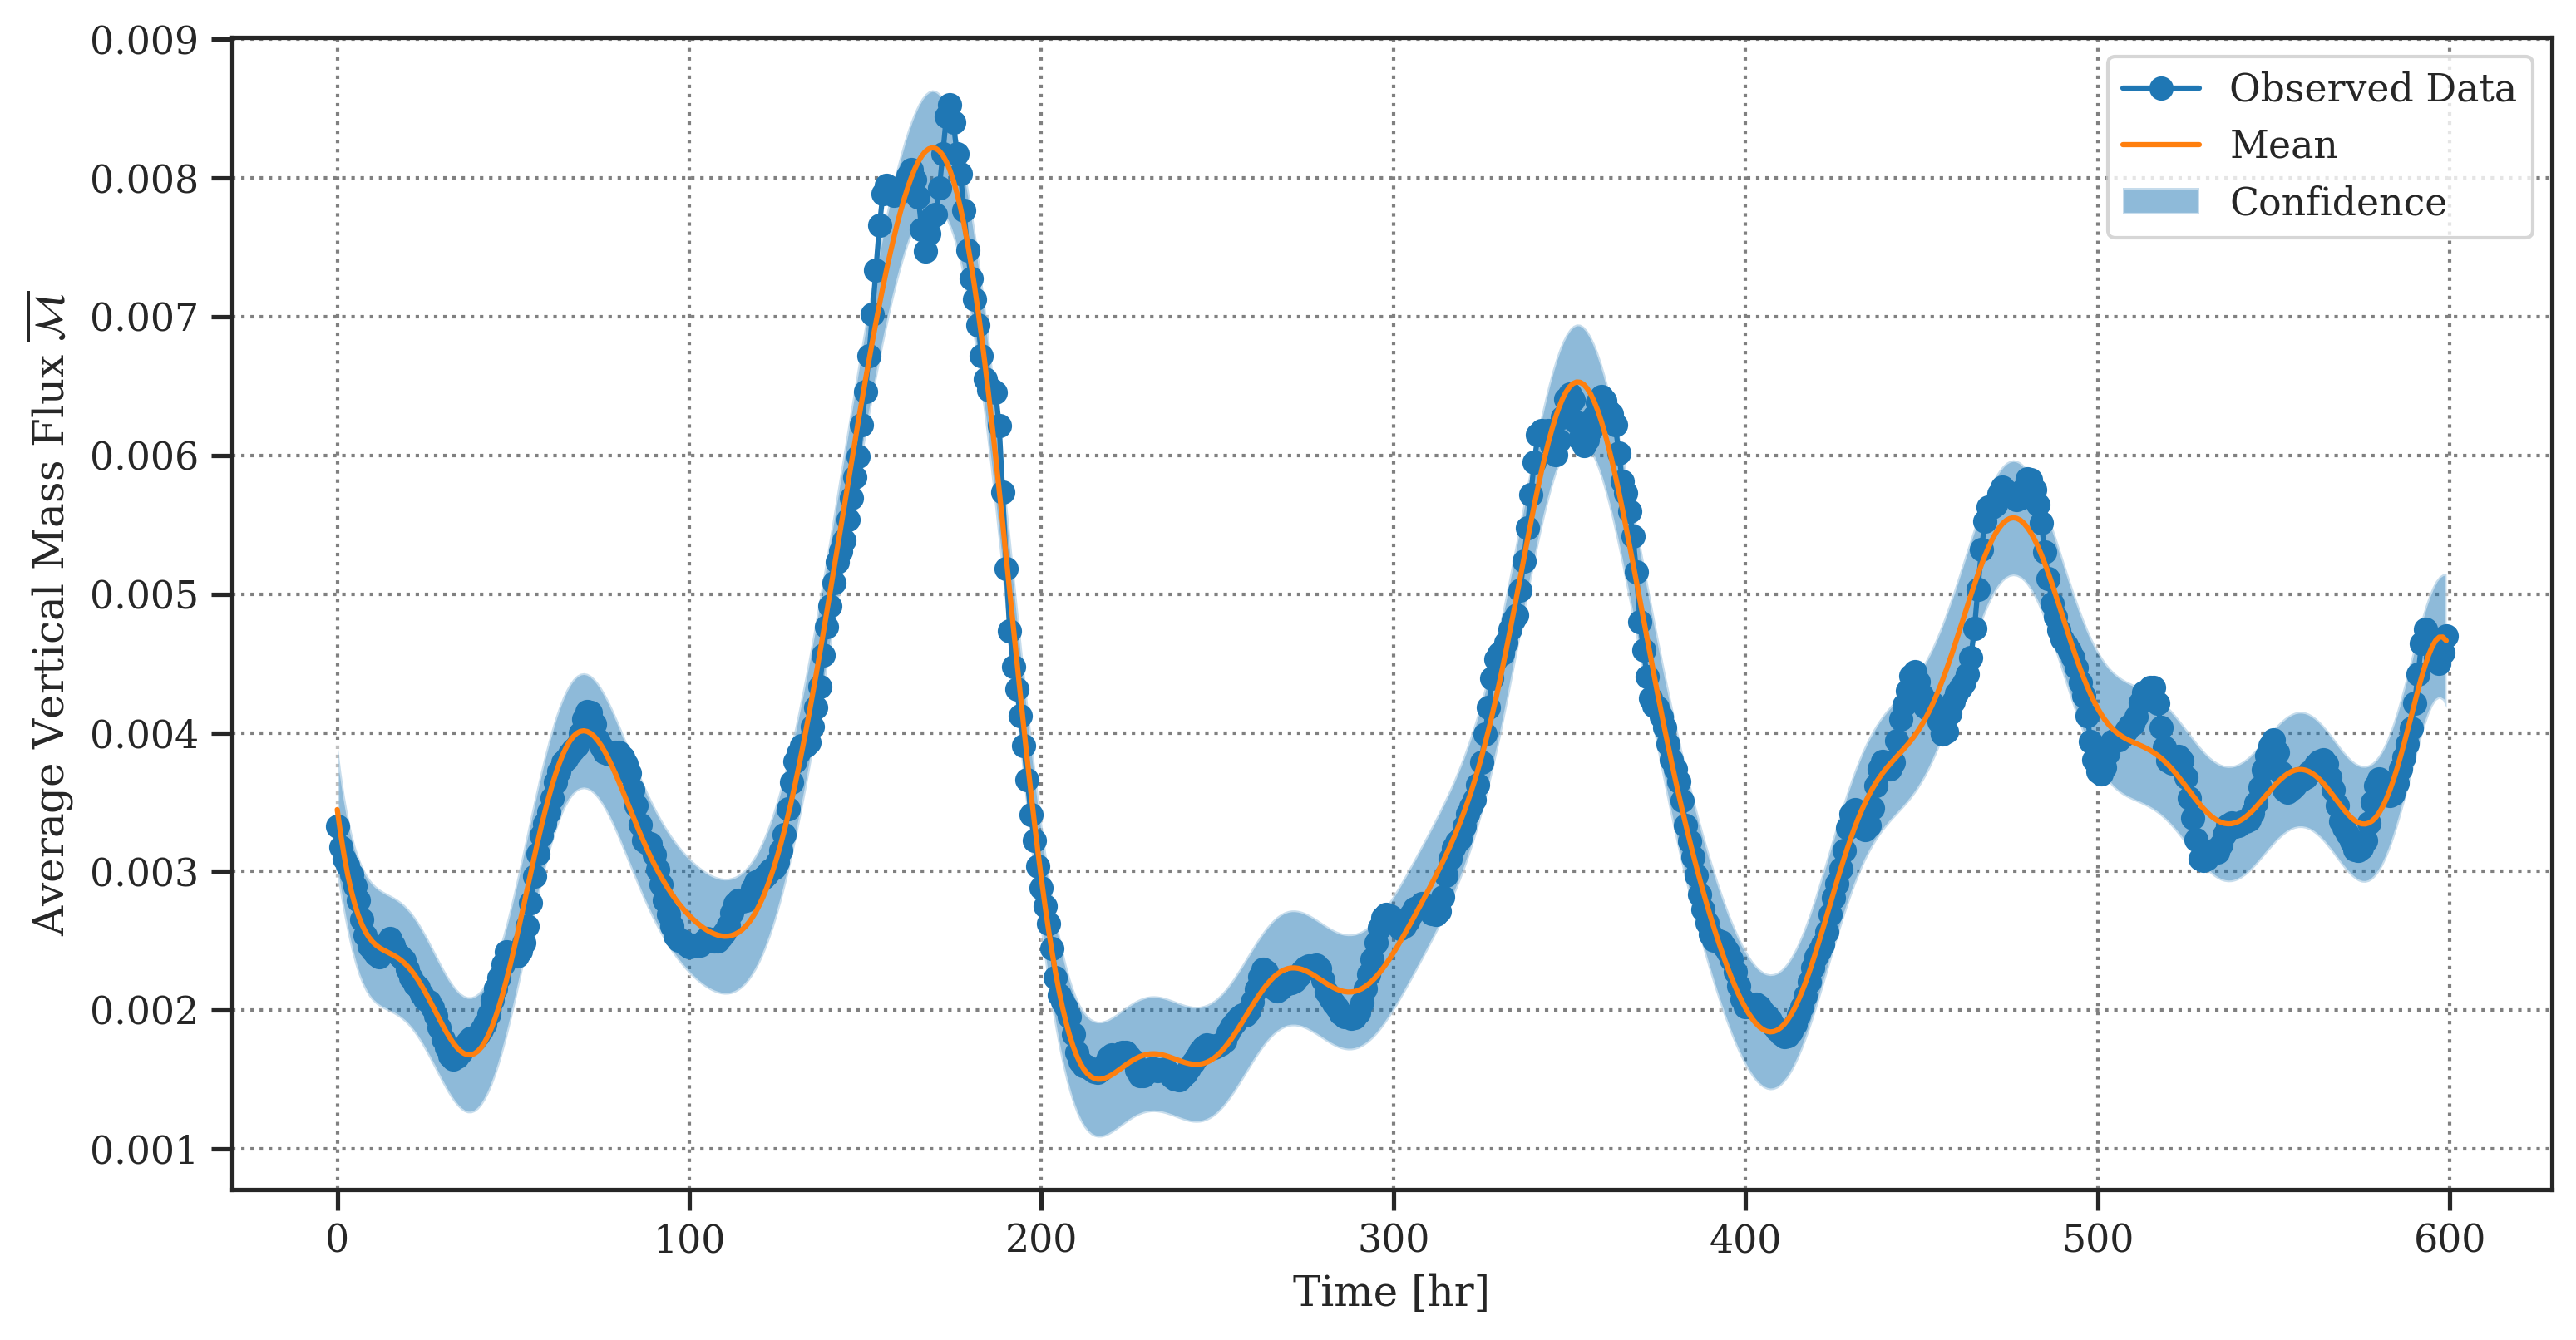

In [185]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad():
    x_test = torch.arange(len(x_tr), dtype=torch.double)
    observed = likelihood(model(x_test))

with torch.no_grad():
    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    lower, upper = observed.confidence_region()

    ax.plot(x_tr.numpy(), y_tr.numpy(), 'o-')
    ax.plot(x_test.numpy(), observed.mean.numpy())
    ax.fill_between(x_test.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)

    ax.set_xlabel("Time [hr]")
    ax.set_ylabel("Average Vertical Mass Flux $\overline{\mathcal{M}}$")

    ax.legend(['Observed Data', 'Mean', 'Confidence'])

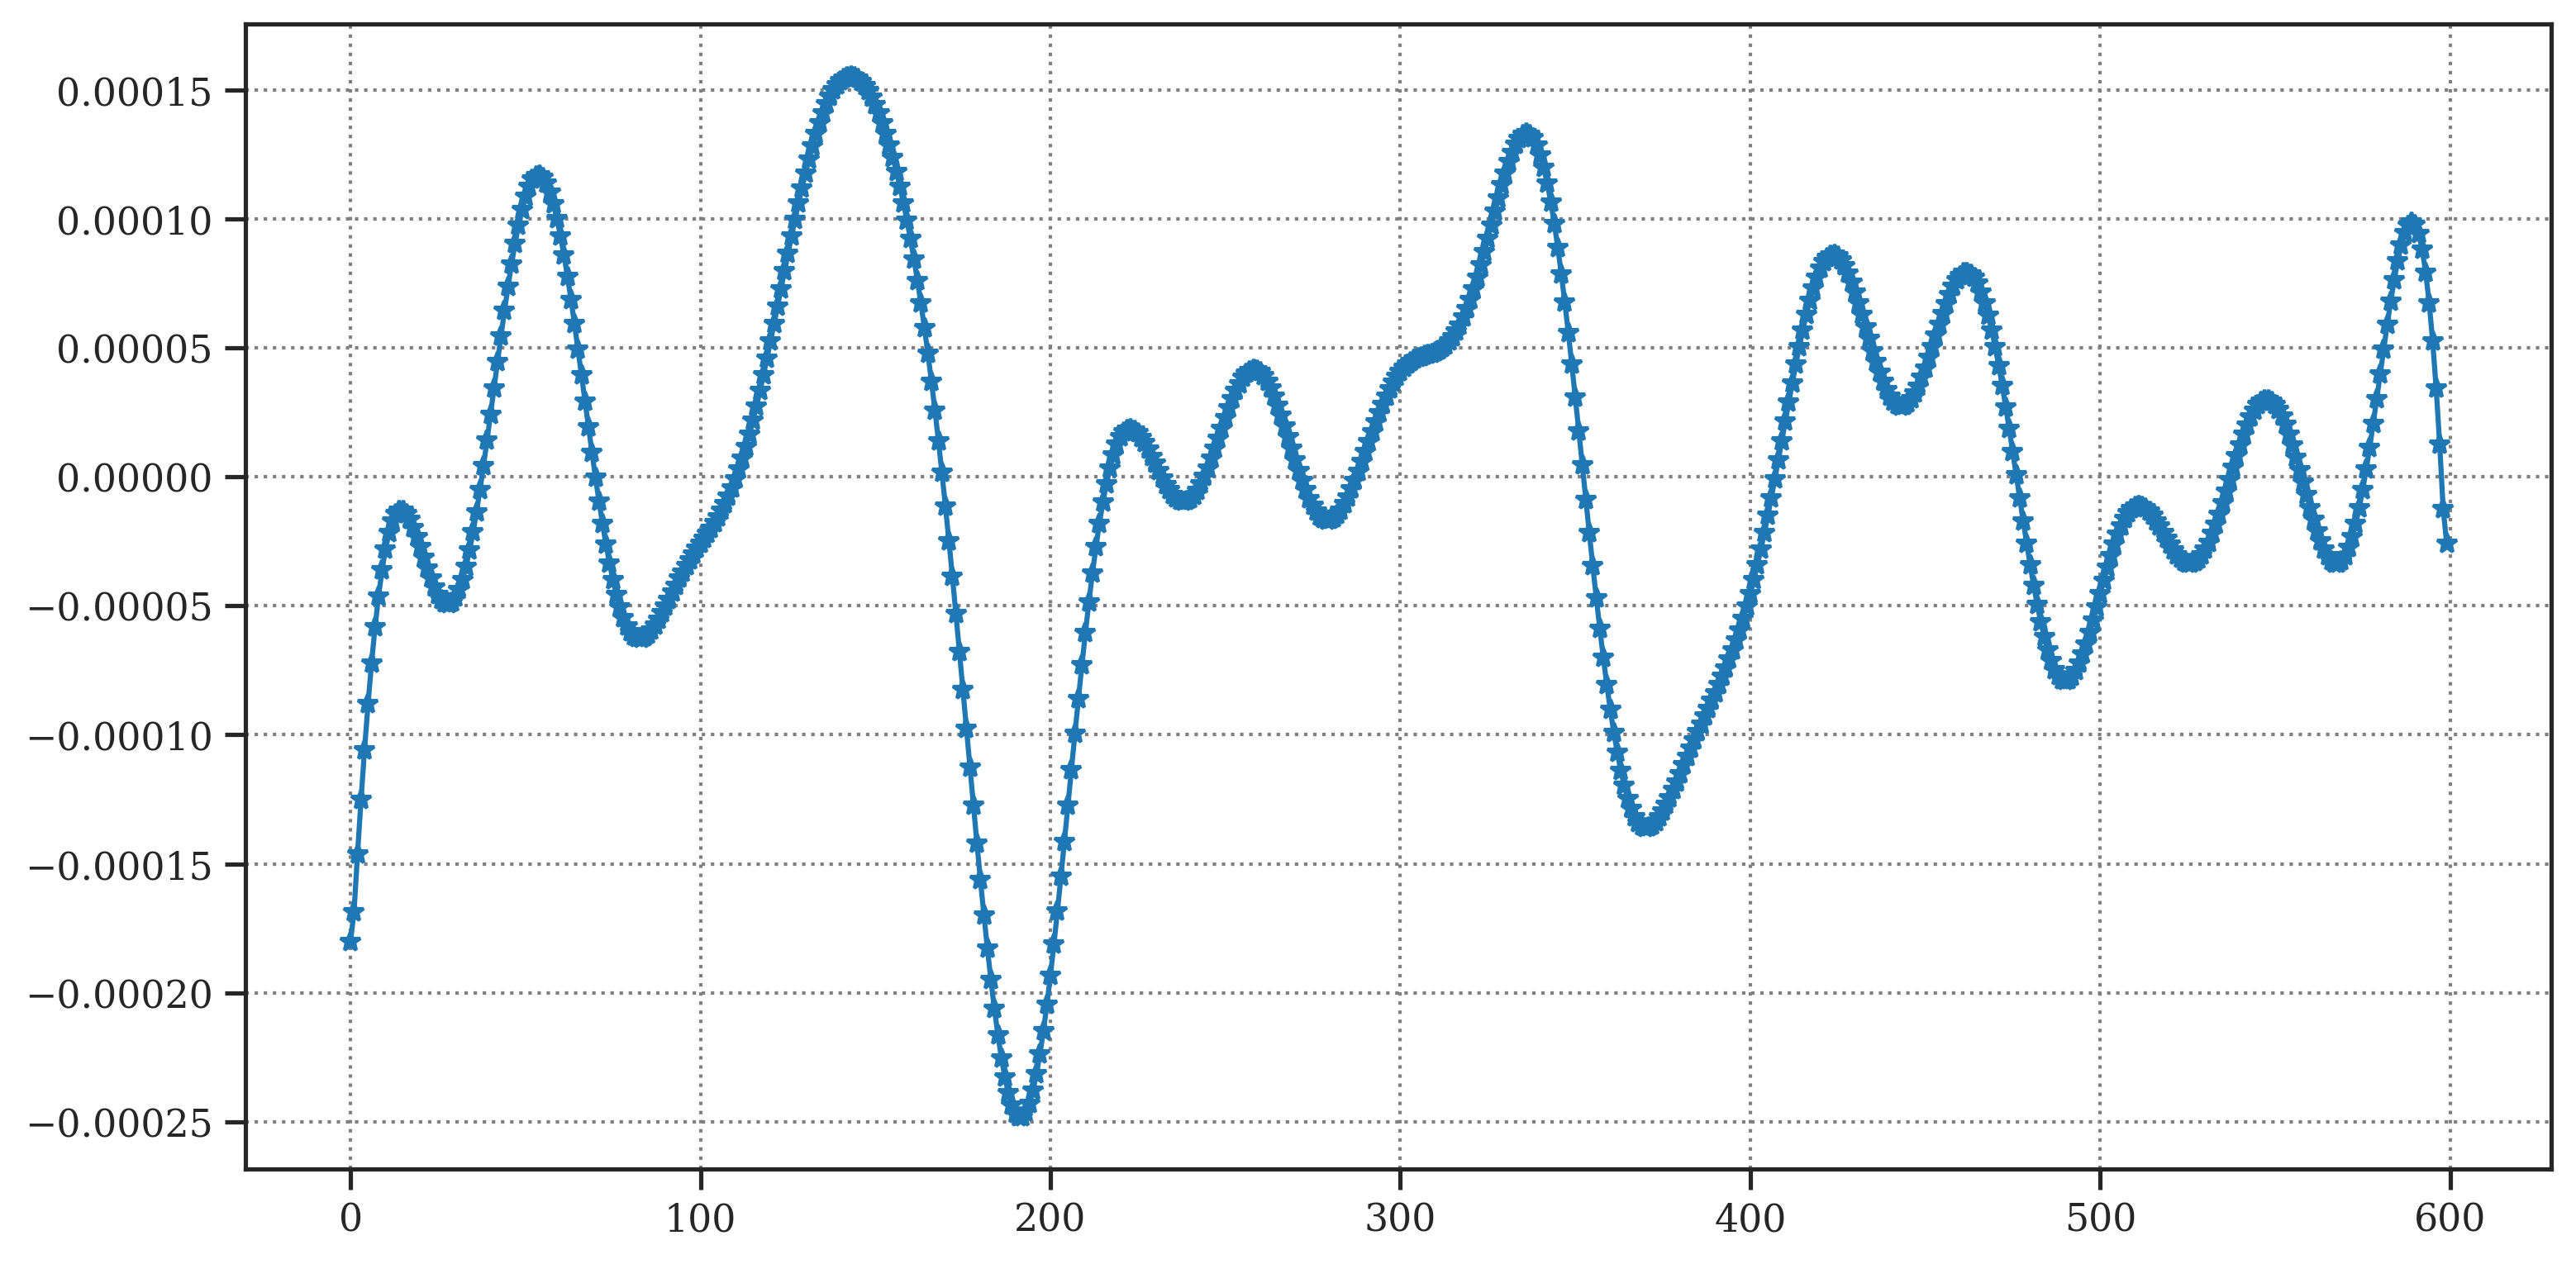

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x_test.numpy(), np.gradient(observed.mean.numpy()), '*-')

y_tr = torch.tensor(np.gradient(observed.mean), dtype=torch.double)
x_tr = torch.tensor(np.arange(len(y_tr)), dtype=torch.double)

In [187]:
class PeriodicGPModel(gpytorch.models.ExactGP):
    def __init__(self, x_tr, y_tr, likelihood):
        super(PeriodicGPModel, self).__init__(x_tr, y_tr, likelihood)
        
        self.mean_module = gpytorch.means.ZeroMean()
        
        self.cov_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PeriodicKernel()
        )

    def forward(self, x):
        x_mean = self.mean_module(x)
        x_cov = self.cov_module(x)
        
        return gpytorch.distributions.MultivariateNormal(x_mean, x_cov)

In [188]:
# Initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint = gpytorch.constraints.Positive(),
    noise_prior = gpytorch.priors.UniformPrior(0, 1),
)
model = PeriodicGPModel(x_tr, y_tr, likelihood)

model.cov_module.base_kernel.initialize(
    lengthscale = torch.tensor(50.),
    period_length = torch.tensor(90.),
)

model.double()

PeriodicGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): UniformPrior(low: 0.0, high: 1.0)
      (raw_noise_constraint): Positive()
    )
  )
  (mean_module): ZeroMean()
  (cov_module): ScaleKernel(
    (base_kernel): PeriodicKernel(
      (raw_lengthscale_constraint): Positive()
      (raw_period_length_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
)

In [189]:
# Model parameters
for param_name, param in model.named_parameters():
    print(f"{param_name:48} \t {param.item()}")
    
print(f"\n {model.cov_module.base_kernel}")

likelihood.noise_covar.raw_noise                 	 0.0
cov_module.raw_outputscale                       	 0.0
cov_module.base_kernel.raw_lengthscale           	 50.0
cov_module.base_kernel.raw_period_length         	 90.0

 PeriodicKernel(
  (raw_lengthscale_constraint): Positive()
  (raw_period_length_constraint): Positive()
)


 And I wish I had access to CUDA cores.

 Edit: We do now! And things are 30x faster with CUDA.

In [190]:
# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam([{'params': model.parameters()},], lr=1e-1)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

max_iter = 300
losses = []

p_bar = tqdm(range(max_iter))
for i in p_bar:
    optimizer.zero_grad()
    output = model(x_tr)
    loss = -mll(output, y_tr)
    losses += [loss.item()]
    loss.backward()

    period = model.cov_module.base_kernel.raw_period_length.item()

    p_status = f"{i + 1:3d}/{max_iter:3d} Loss: {loss.item():.3f} Period: {period:.3f}"
    p_bar.set_description(p_status)
    
    optimizer.step()

  0%|          | 0/300 [00:00<?, ?it/s]

In [191]:
# Model parameters
for param_name, param in model.named_parameters():
    if (param_name == "cov_module.base_kernel.raw_period_length"):
        tr_period = param.clone().detach()

    print(f"{param_name:42} \t {param.item()}")

likelihood.noise_covar.raw_noise           	 -19.343494253736445
cov_module.raw_outputscale                 	 -16.015668519532923
cov_module.base_kernel.raw_lengthscale     	 51.18785423982329
cov_module.base_kernel.raw_period_length   	 95.21380875663985


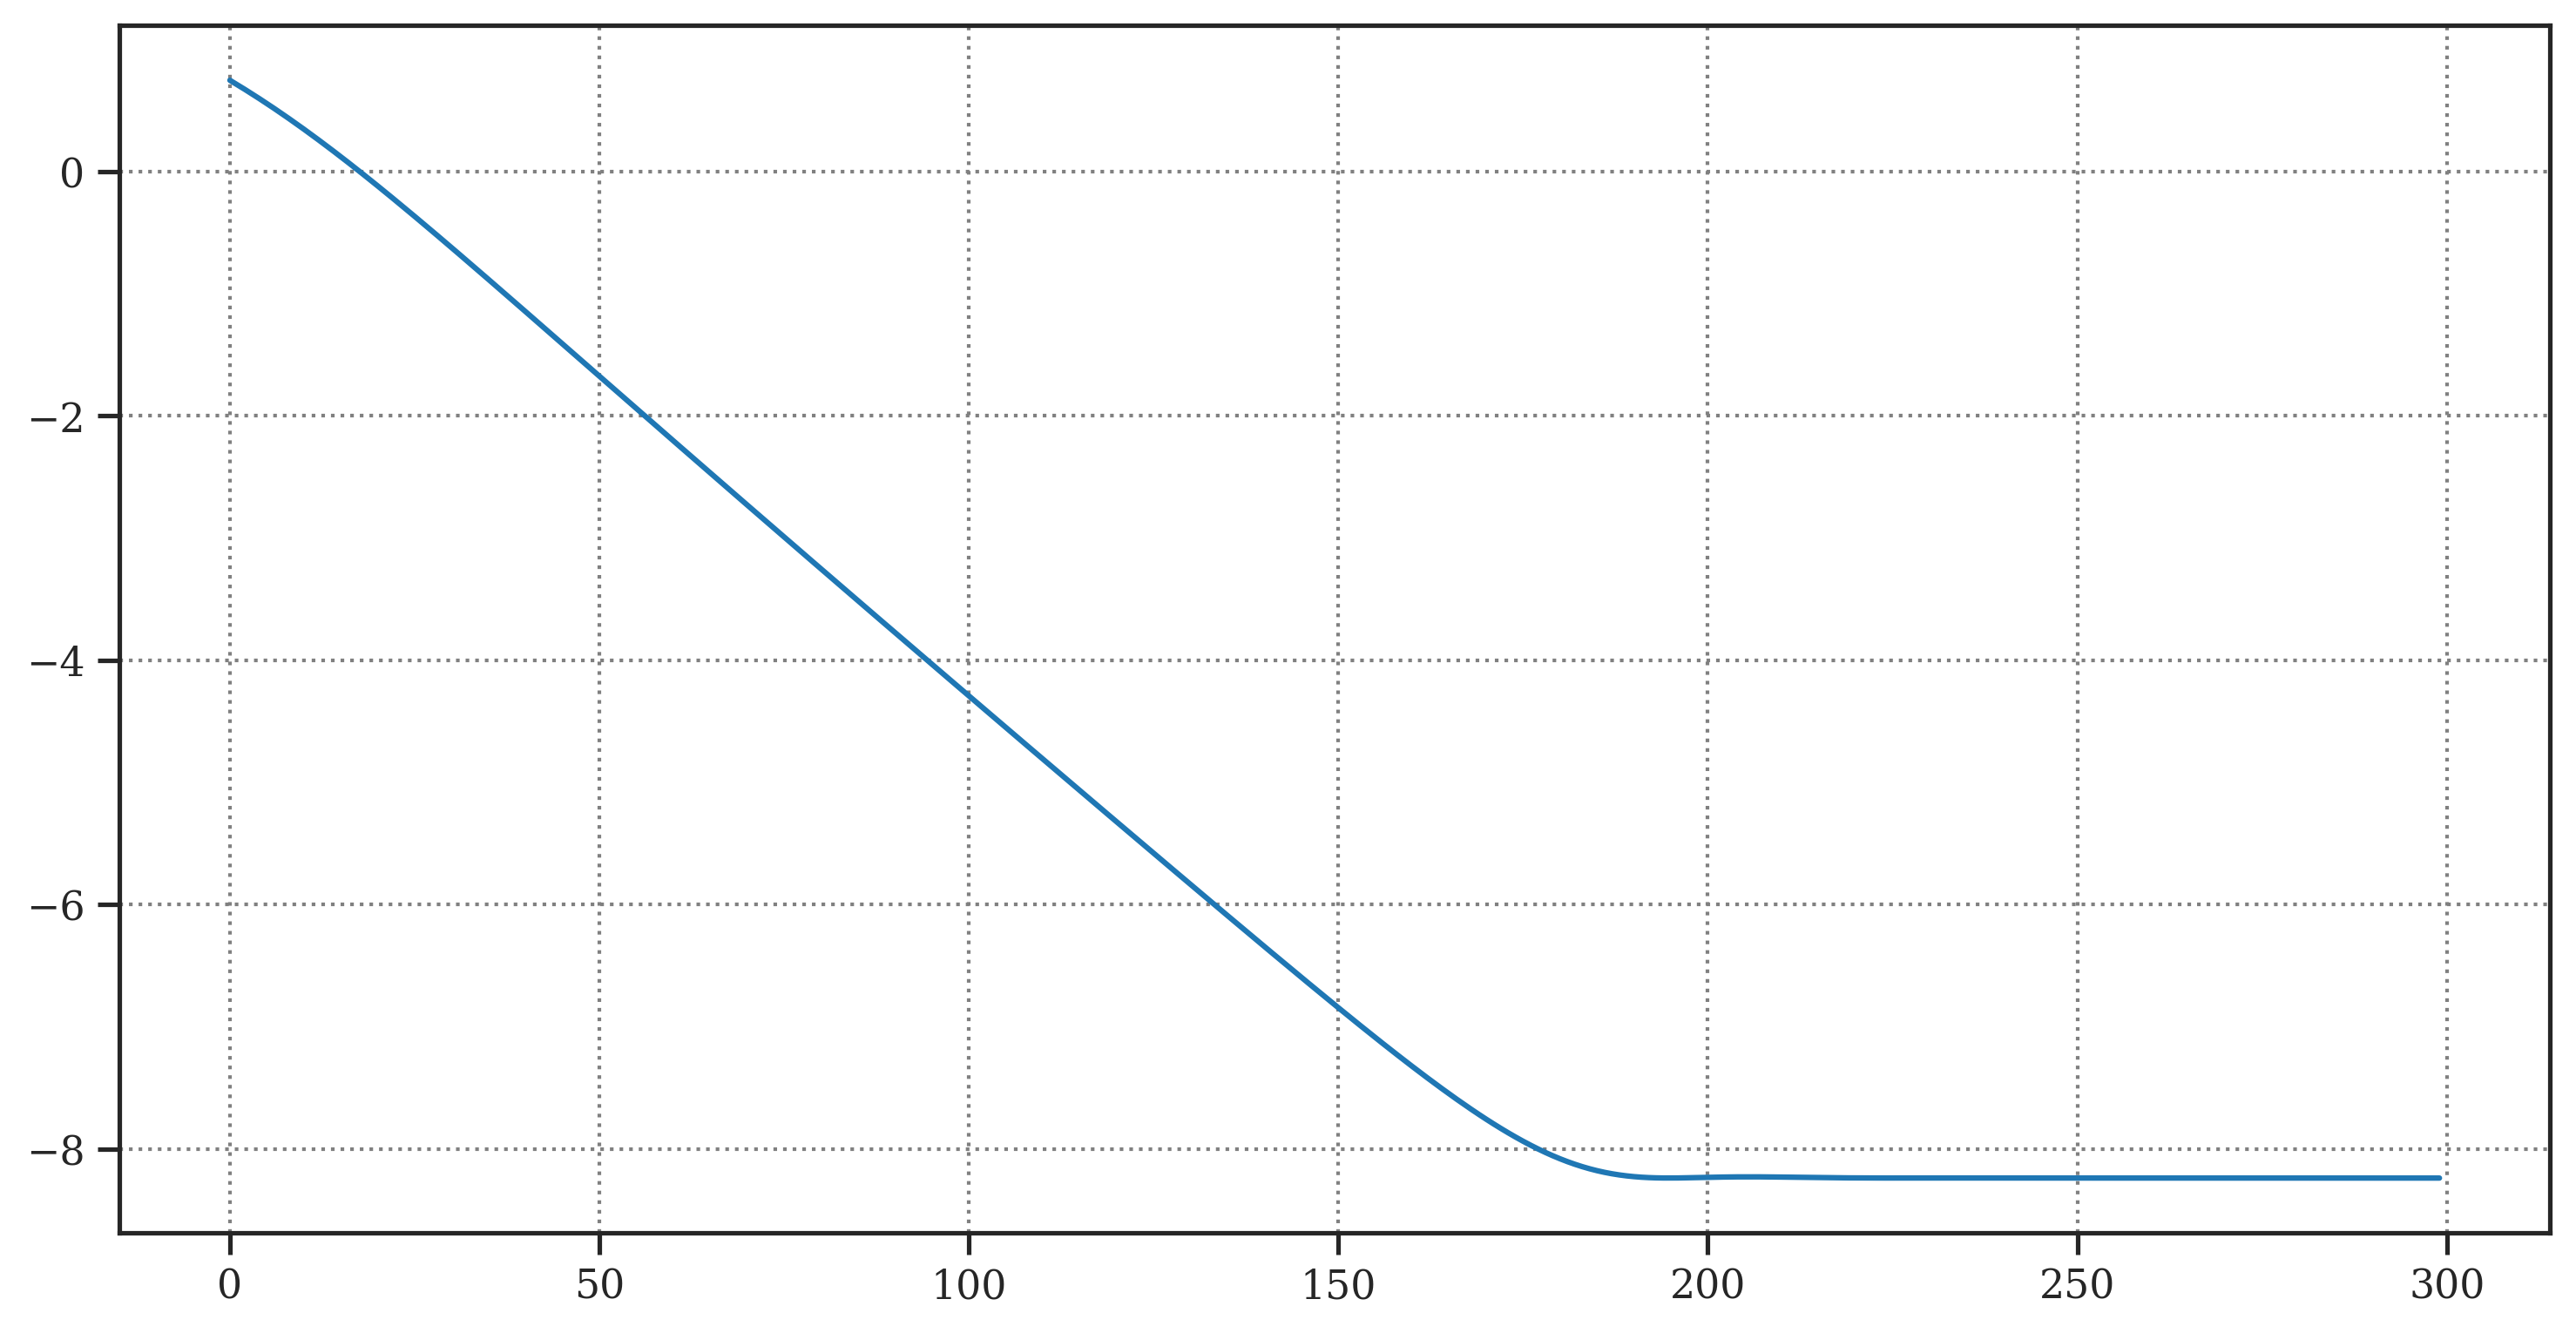

In [192]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(np.arange(len(losses)), losses)

In [193]:
print(mll)

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): UniformPrior(low: 0.0, high: 1.0)
      (raw_noise_constraint): Positive()
    )
  )
  (model): PeriodicGPModel(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): UniformPrior(low: 0.0, high: 1.0)
        (raw_noise_constraint): Positive()
      )
    )
    (mean_module): ZeroMean()
    (cov_module): ScaleKernel(
      (base_kernel): PeriodicKernel(
        (raw_lengthscale_constraint): Positive()
        (raw_period_length_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)


In [194]:
dt = 120

# Make predictions by feeding model through likelihood
x_test = torch.arange(x_tr.size(dim=0) + dt, dtype=torch.double)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed = likelihood(model(x_test))
    y_mean = observed.mean
    lower, upper = observed.confidence_region()

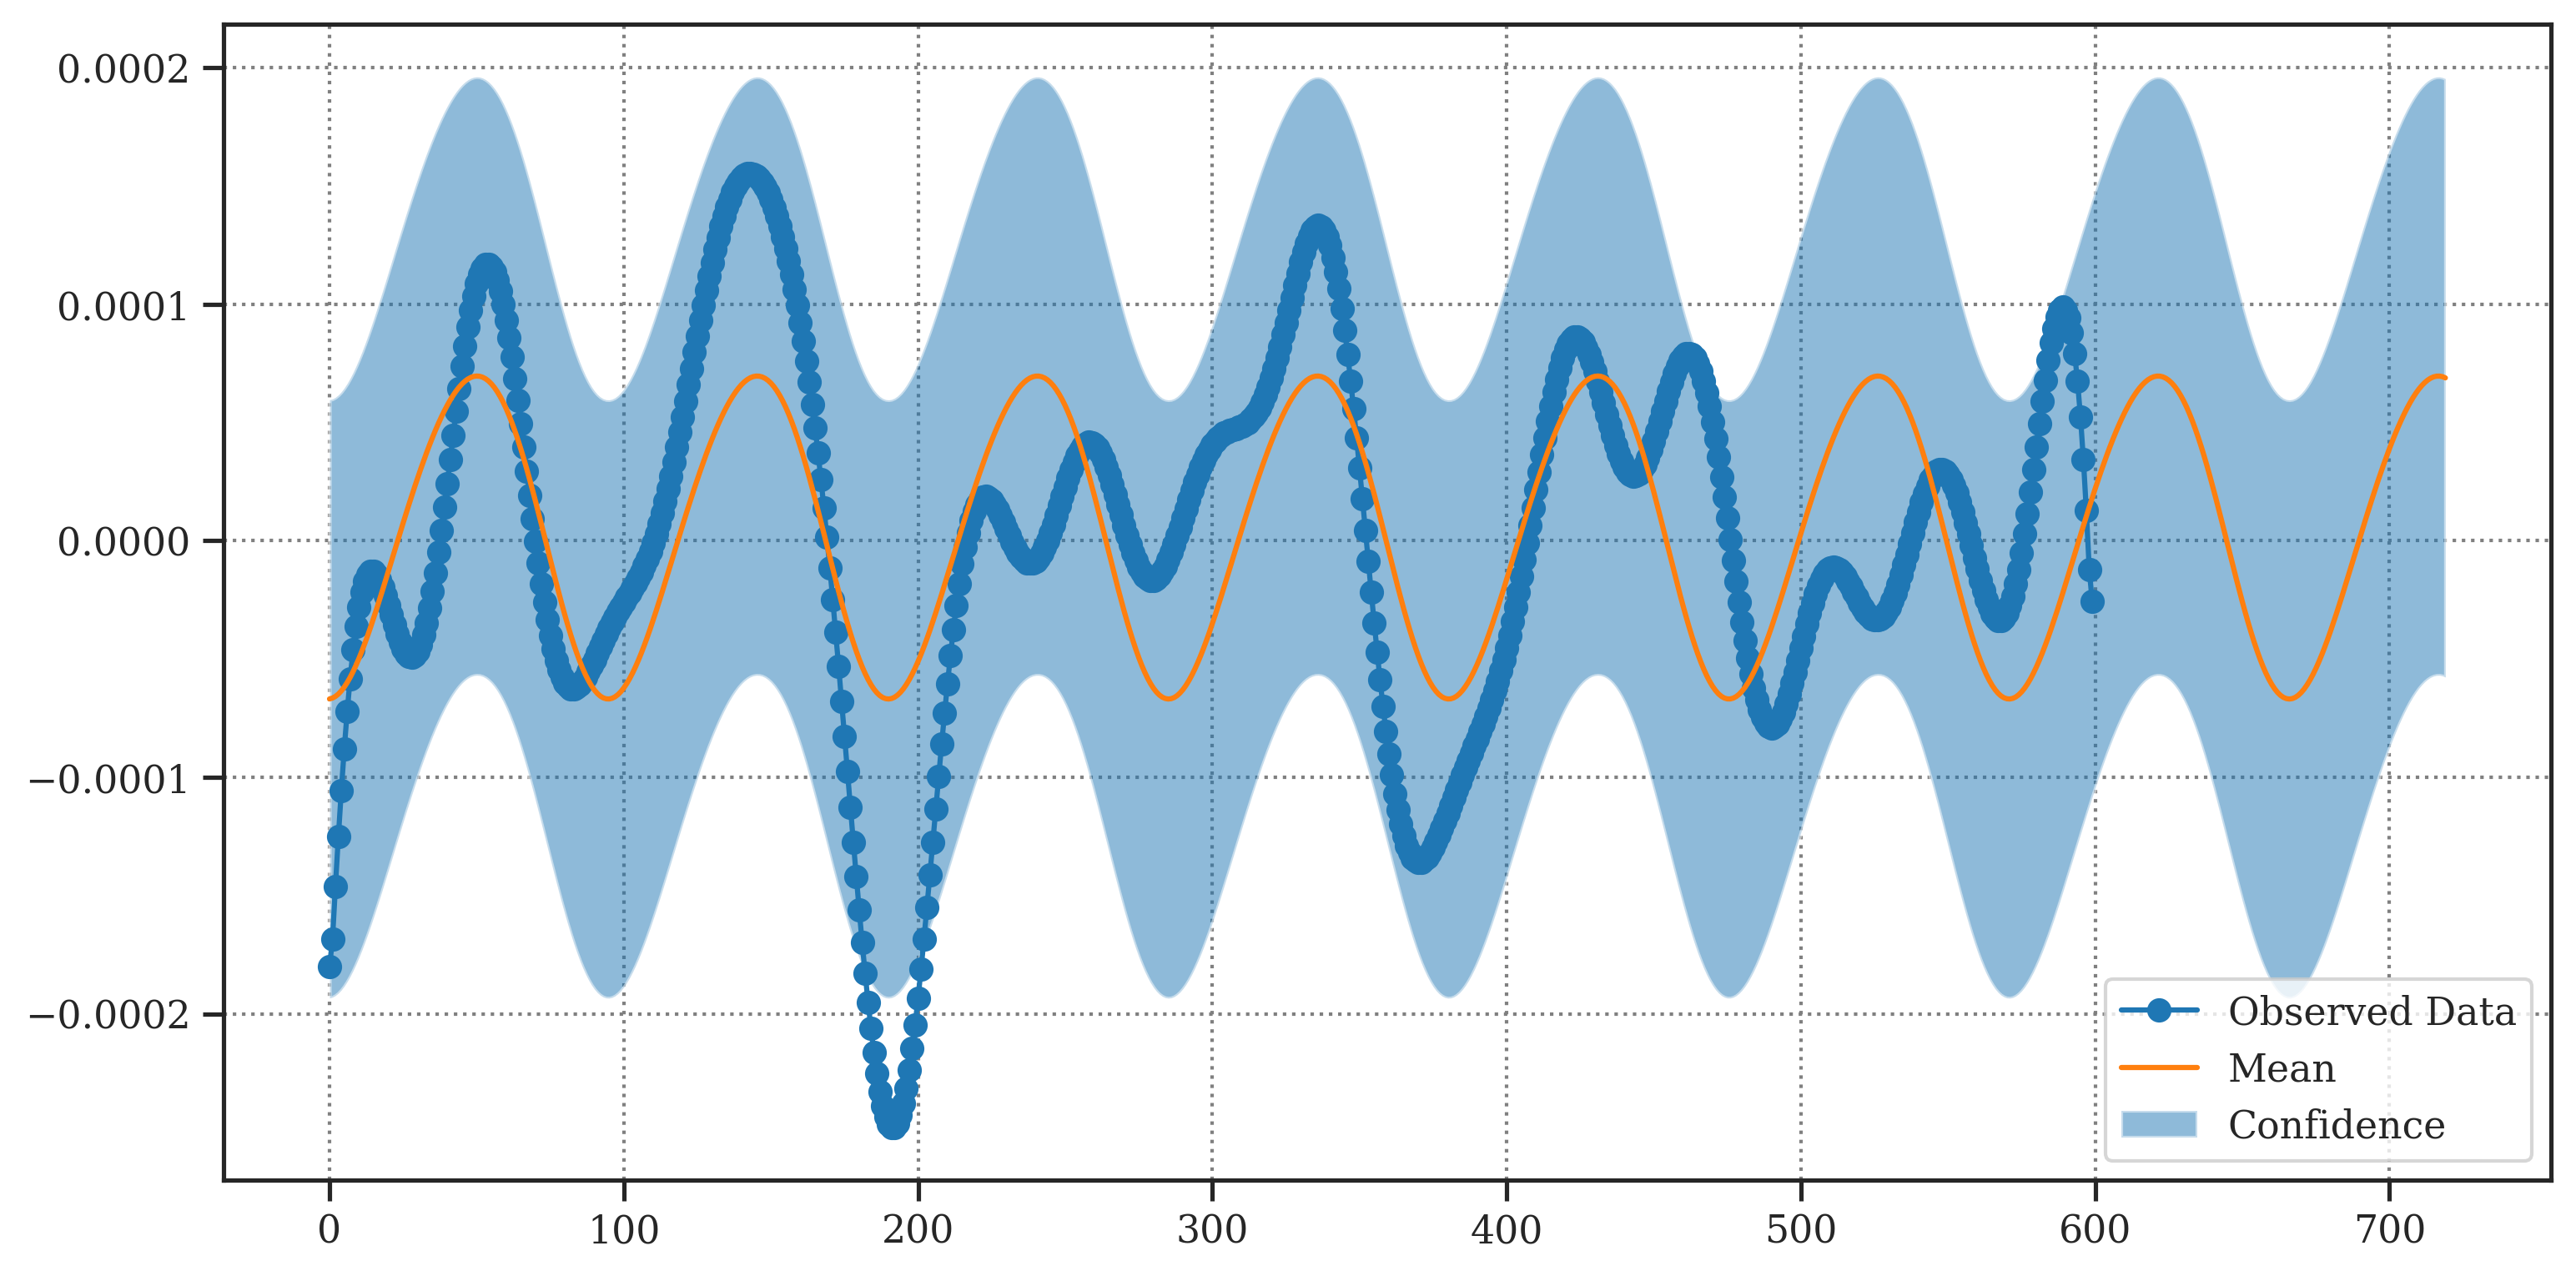

In [195]:
with torch.no_grad():
    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    lower, upper = observed.confidence_region()
    
    ax.plot(x_tr.numpy(), y_tr.numpy(), 'o-')
    ax.plot(x_test, y_mean)
    ax.fill_between(x_test.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

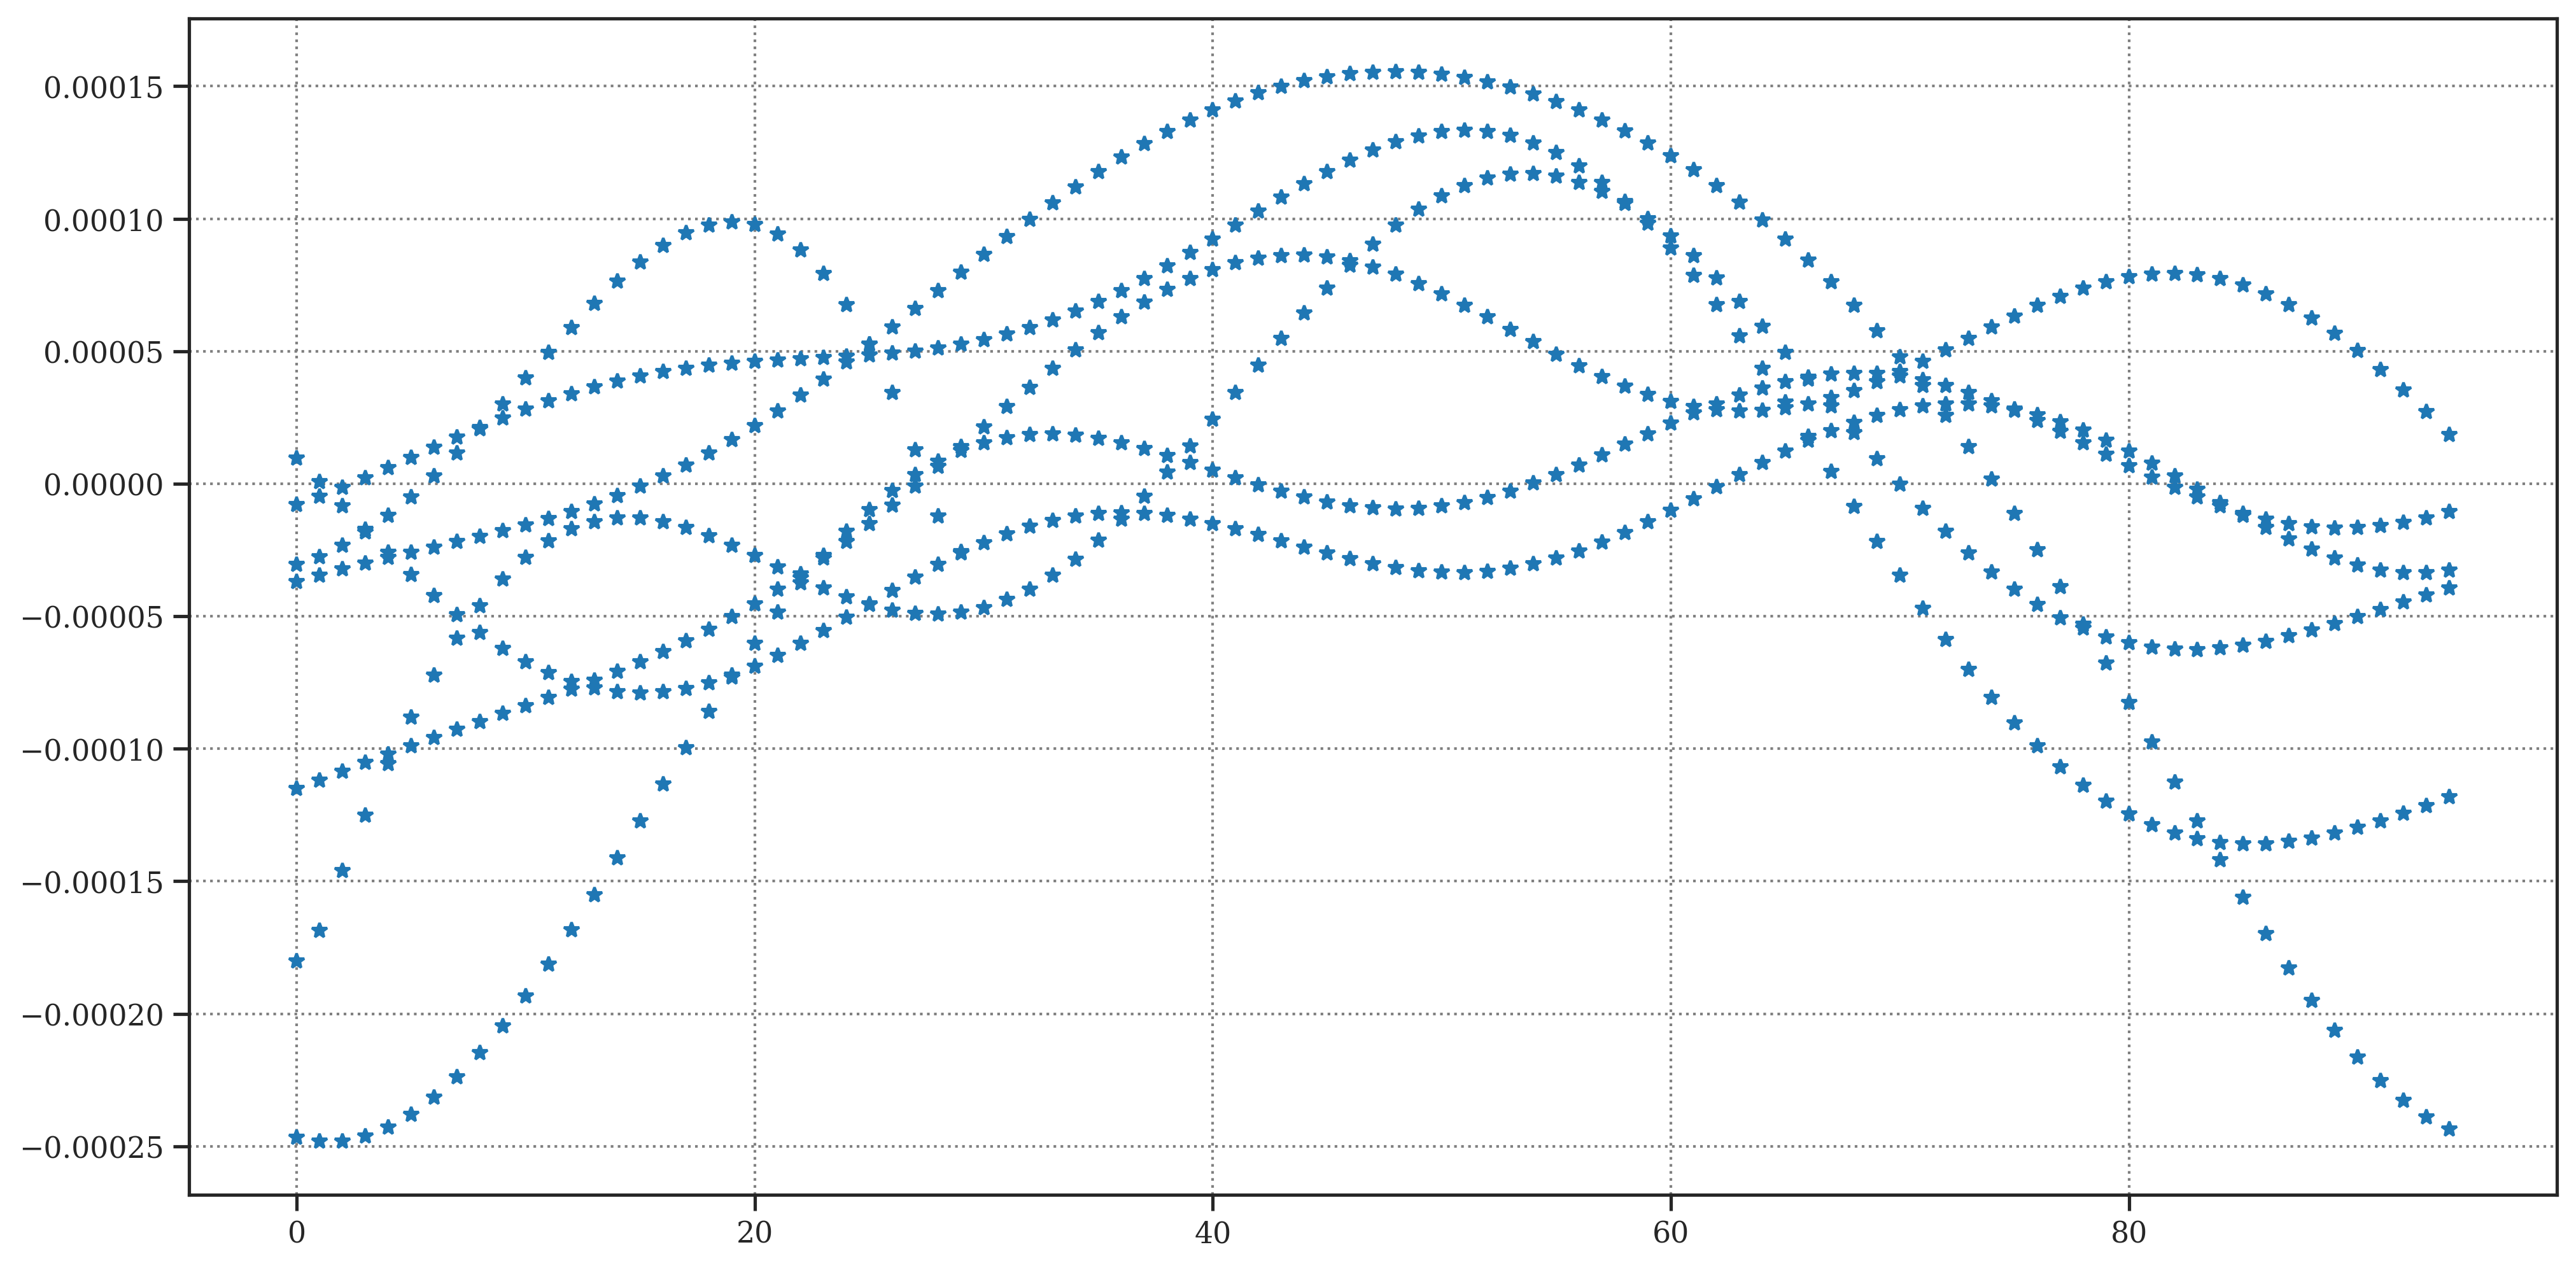

In [196]:
# Redefine training domain
x_tr_rep = np.mod(x_tr, int(tr_period))

# Plot
fig, ax = plt.subplots(1, 1, figsize = (16, 8))
ax.plot(x_tr_rep, y_tr, '*')

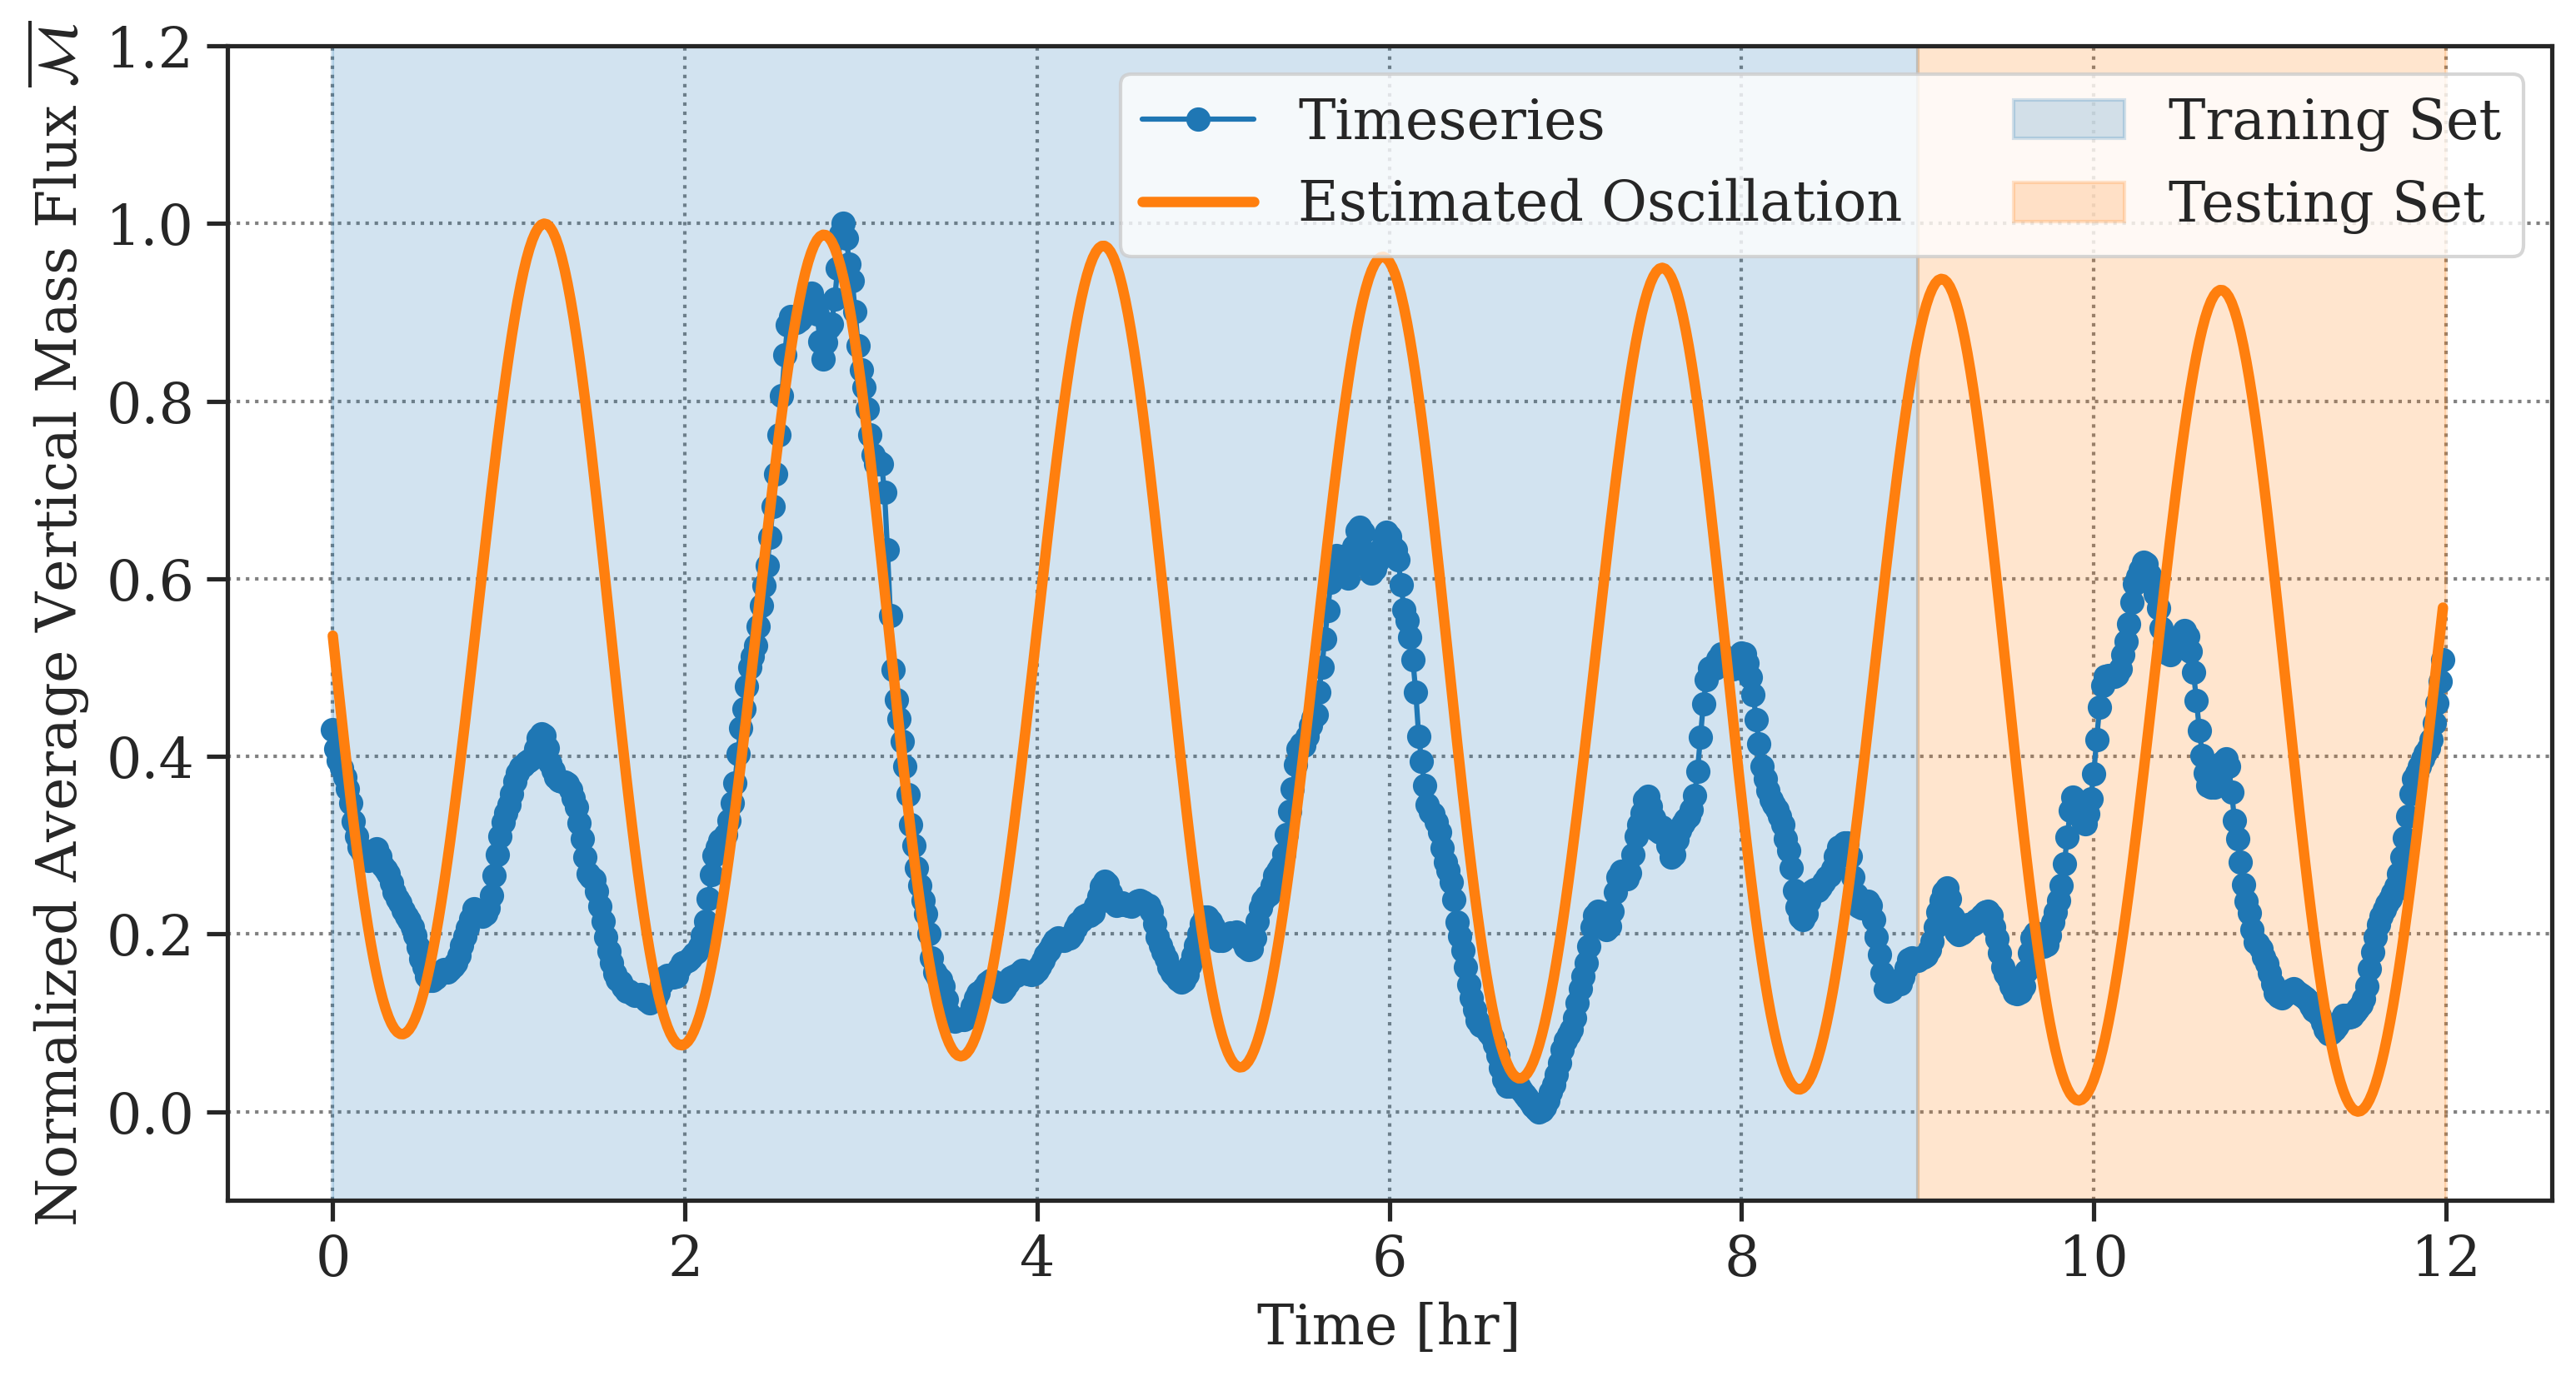

In [197]:
y_pr = y_mean.numpy()
y_pr = np.cumsum(y_pr - np.mean(y_pr, axis=0))

y_sl = y_full[:720] - sl.lowess(y_full[:720], x_full[:720], return_sorted=False, frac=0.3)

x_c = np.arange(len(y_full)) / 60
x_t = np.arange(len(x_test)) / 60

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=300)

ax.plot(x_c,
    skl_prep.minmax_scale(y_sl[:, None], axis=0),
    "o-",
    label="Timeseries")
ax.plot(
    x_t[:720],
    skl_prep.minmax_scale(y_pr[:720, None], axis=0),
    "-",
    lw=3,
    label="Estimated Oscillation",
)

ax.axvspan(0, 9, alpha=0.2, color="C0", label="Traning Set")
ax.axvspan(9, 12, alpha=0.2, color="C1", label="Testing Set")

ax.legend(loc=0, ncol=2, frameon=True, fontsize=16)

ax.set_ylim([-0.1, 1.2])

ax.set_xlabel("Time [hr]", fontsize=16)
ax.set_ylabel("Normalized Average Vertical Mass Flux $\overline{\mathcal{M}}$", fontsize=16)

ax.tick_params(axis="both", which="major", labelsize=16)

 It is, then, not surprising to see that the slope of the cloud size distribution and total mass flux are closely related. What is surprising, and perhaps more important, is that it is also very closely related to cloud cover. That is, total cloud cover over a domain also oscillates with total mass flux and the cloud size distribution. I won't repeat the GP regression for cloud cover, because it will be exactly same as this one.

 Given the result, one cloud look at the cloud cover over time and infer the strength of mass flux (and naturally, entrainment) over the cloud field. Also, we can perform a GP regression in 2-dimensional (height, time) space using the vertial mass flux (or entrainment) profile. Because both mass flux entrainment appear to oscillate with a 92-minute period while maintaining the general shape of the vertical profile, it means that the uncertainty involved in calculating the mean vertical mass flux and entrainment profiles will be a lot smaller once we account for the the oscillation.

In [198]:
p = Path("../nc/CGILS_25m_1s_nop.nc")
df = xr.open_dataset(p)

y_mf = np.array(np.nanmean(df.MFCOR.T, axis=0)[720:])
y_cld = np.array(df.CLDSHD[720:])

x_c = np.arange(len(y_cld)) / 60

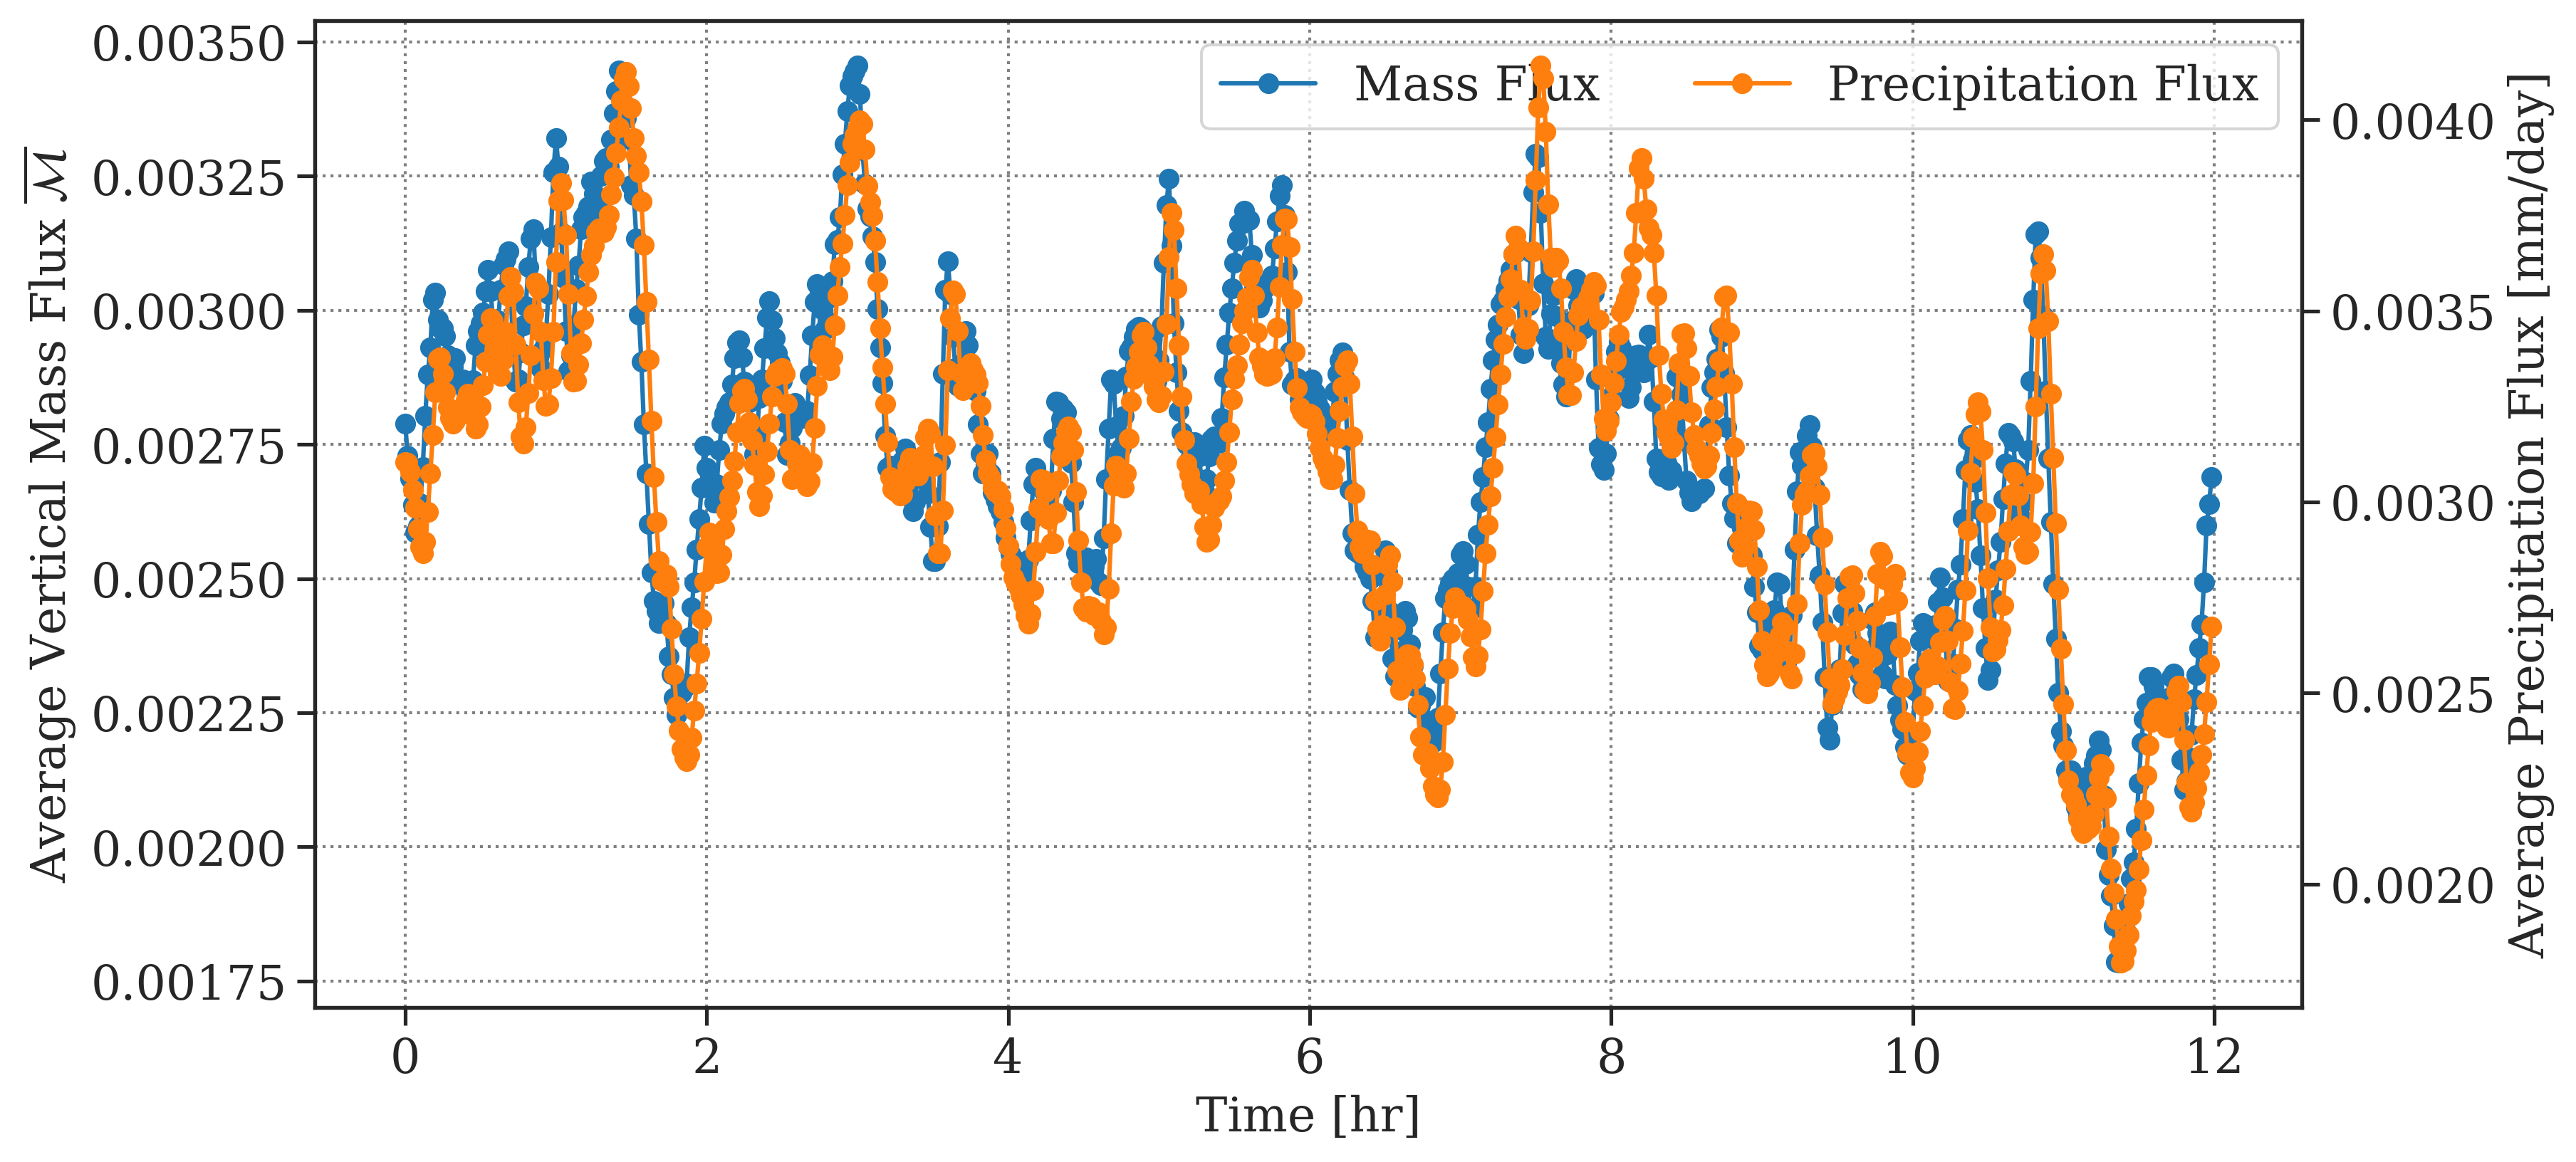

In [199]:
y_mf = np.array(np.nanmean(df.MFCOR.T, axis=0)[720:])
y_prec = np.nanmean(df.PRECIP[720:], axis=1)

x_c = np.arange(len(y_cld[:720])) / 60

# Plot
fig, ax = plt.subplots(1, 1, figsize = (12, 6), dpi=300)

ax_t = ax.twinx()

ln1 = ax.plot(x_c, y_mf[:, None], 'o-', c="C0", label='Mass Flux')

ax.set_xlabel("Time [hr]", fontsize=16)
ax.set_ylabel("Average Vertical Mass Flux $\overline{\mathcal{M}}$", fontsize=16)

ln2 = ax_t.plot(x_c, y_prec[:, None], 'o-', c="C1", label="Precipitation Flux")

ax_t.set_ylabel("Average Precipitation Flux [mm/day]", fontsize=16)

ax_t.grid(False)

# Construct legend for both plots
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=1, ncol=2, frameon=True, fontsize=16)

ax.tick_params(axis="both", which="major", labelsize=16)
ax_t.tick_params(axis="both", which="major", labelsize=16)